# Import LIbrary

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score



In [66]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df

# Explore Data

In [67]:
df = pd.read_csv(r'E:\task_depi\ML_Workshop_Customer360\data\customer_360_ml_workshop.csv')
df

,CustomerID,Age,Region,TenureMonths,ContractType,InternetType,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,PaperlessBilling,AutoPay,SatisfactionScore,Future12MRevenueEGP,Churn
0,CUST-00001,22,Alexandria,23,Month-to-month,DSL,317.9,580.48,5,5,0,Yes,Yes,5.0,6287.08,Yes
1,CUST-00002,59,Upper Egypt,9,Month-to-month,4G/5G,359.3,434.36,1,1,1,No,Yes,4.0,4619.91,No
2,CUST-00003,52,Giza,21,Month-to-month,DSL,176.9,391.35,3,5,1,Yes,Yes,5.0,4512.25,No
3,CUST-00004,41,Giza,12,Month-to-month,DSL,312.5,420.40,3,2,1,No,Yes,5.0,3809.65,No
4,CUST-00005,40,Delta,21,Month-to-month,4G/5G,191.6,462.73,3,4,0,No,Yes,3.0,4731.09,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,CUST-02996,51,Giza,14,One year,4G/5G,257.8,530.46,4,2,2,Yes,Yes,2.0,6353.49,No
2996,CUST-02997,33,Giza,36,Two year,Fiber,158.8,438.19,2,4,0,Yes,Yes,4.0,5956.22,No
2997,CUST-02998,36,Giza,20,Month-to-month,DSL,351.5,569.98,5,3,0,Yes,Yes,4.0,6233.85,No
2998,CUST-02999,41,Delta,4,One year,DSL,130.4,459.19,5,1,0,Yes,Yes,4.0,5590.18,Yes


In [68]:
segmentation_features = [
    'TenureMonths', 
    'MonthlyUsageGB', 
    'MonthlyChargeEGP', 
    'NumServices', 
    'SupportCalls6M', 
    'LatePayments12M', 
    'SatisfactionScore'
]

In [69]:
X_seg = df[segmentation_features].copy()

In [70]:
data_info(X_seg)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,TenureMonths,int64,"[19, 9, 14, 17, 15, 22, 18, 21, 12, 8]",72,0,0.0,0
1,MonthlyUsageGB,float64,"[10.0, 196.3, 241.6, 200.6, 174.8, 214.7, 149....",1920,75,2.5,0
2,MonthlyChargeEGP,float64,"[384.98, 420.4, 542.19, 547.93, 555.22, 436.42...",2893,0,0.0,0
3,NumServices,int64,"[6, 3, 4, 1, 5, 2]",6,0,0.0,0
4,SupportCalls6M,int64,"[2, 1, 3, 0, 4, 5, 6, 7, 9, 8]",10,0,0.0,0
5,LatePayments12M,int64,"[1, 0, 2, 3, 4, 5, 6]",7,0,0.0,0
6,SatisfactionScore,float64,"[4.0, 3.0, 5.0, 2.0, 1.0]",5,60,2.0,0


# Nulls

In [73]:
for col in segmentation_features:
    X_seg[col] = pd.to_numeric(X_seg[col], errors='coerce')
    if X_seg[col].isnull().sum() > 0:
        median_val = X_seg[col].median()
        X_seg[col] = X_seg[col].fillna(median_val)

print("Total remaining NaNs in X_seg:", X_seg.isnull().sum().sum())


Total remaining NaNs in X_seg: 0


# Scaling

In [74]:

scaler = StandardScaler()
X_seg_scaled = scaler.fit_transform(X_seg)

print("X_seg_scaled is ready! Shape:", X_seg_scaled.shape)

X_seg_scaled is ready! Shape: (3000, 7)


# kmeans

In [76]:
k_values = range(2, 11)
inertia_values = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_seg_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_seg_scaled, labels))

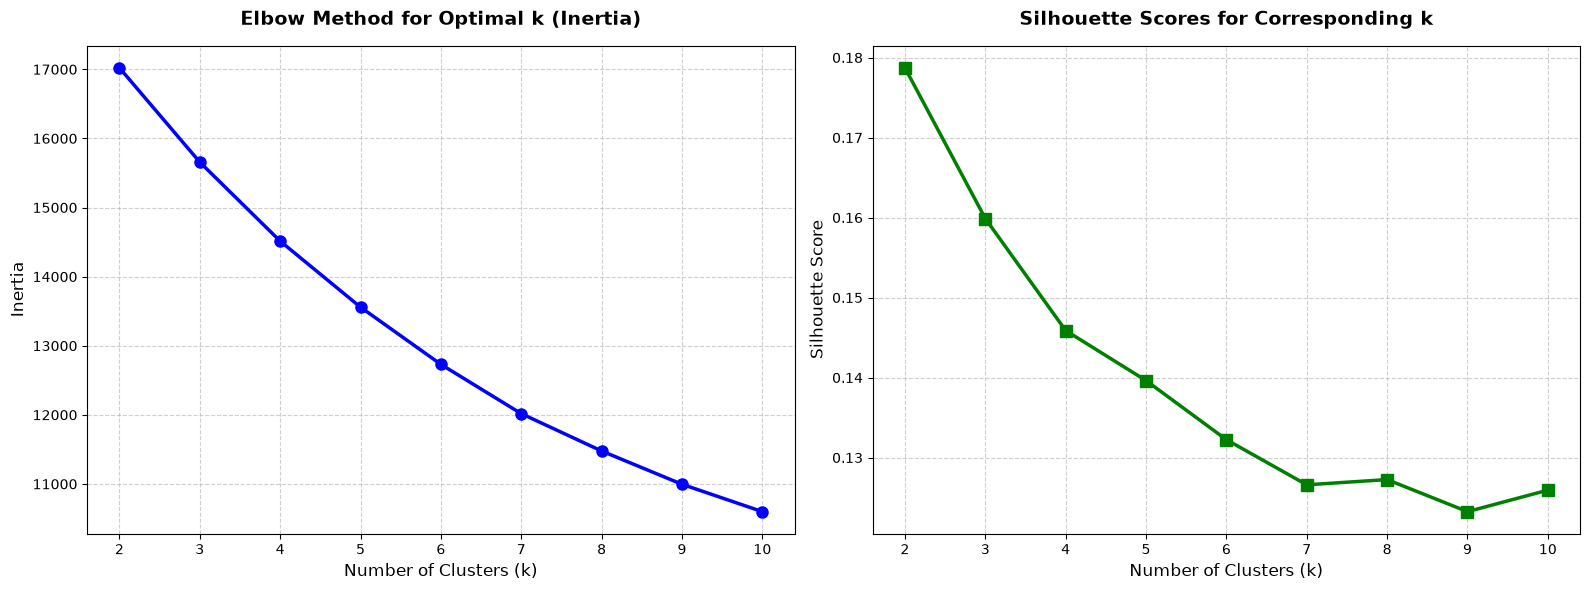

In [77]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# Elbow Method Plot
ax1.plot(k_values, inertia_values, marker='o', color='b', linewidth=2.5, markersize=8)
ax1.set_title('Elbow Method for Optimal k (Inertia)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Silhouette Score Plot
ax2.plot(k_values, silhouette_scores, marker='s', color='g', linewidth=2.5, markersize=8)
ax2.set_title('Silhouette Scores for Corresponding k', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


#### Insight:
Selected Optimal k = 4 based on Elbow bend and Silhouette Score balance.

In [78]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_seg_scaled)

In [ ]:
df['Cluster_KMeans'] = cluster_labels

In [81]:
cluster_names = {
    0: 'Loyal High-Value Customers',
    1: 'At-Risk / Churn-Prone',
    2: 'New / Low-Engagement',
    3: 'Budget / Standard Users'
}

df['Segment_Name'] = df['Cluster_KMeans'].map(cluster_names)

In [83]:
cluster_profile = df.groupby('Segment_Name')[segmentation_features].mean().round(2)
print(" Customer Segments Business Profiles:")
display(cluster_profile)

 Customer Segments Business Profiles:


,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore
Segment_Name,,,,,,,
At-Risk / Churn-Prone,53.77,238.18,472.16,3.22,2.03,1.04,3.53
Budget / Standard Users,20.38,244.98,588.91,5.00,2.27,0.59,3.53
Loyal High-Value Customers,21.63,230.68,525.76,4.16,2.17,2.69,3.44
New / Low-Engagement,19.82,212.46,379.45,1.92,2.24,0.85,3.45


# Agglomerative Clustering

In [85]:
agg_clustering = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df['Cluster_Agglomerative'] = agg_clustering.fit_predict(X_seg_scaled)

In [86]:
agg_silhouette = silhouette_score(X_seg_scaled, df['Cluster_Agglomerative'])
print(f" Agglomerative Clustering Silhouette Score (k={4}): {agg_silhouette:.4f}")

 Agglomerative Clustering Silhouette Score (k=4): 0.0825


# DBSCAN

In [87]:
dbscan = DBSCAN(eps=1.8, min_samples=15)
dbscan_labels = dbscan.fit_predict(X_seg_scaled)
df['Cluster_DBSCAN'] = dbscan_labels



In [88]:
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f" DBSCAN Result:")
print(f"   - Estimated number of clusters: {n_clusters_dbscan}")
print(f"   - Estimated number of noise/outlier points (Label -1): {n_noise}")

 DBSCAN Result:
   - Estimated number of clusters: 1
   - Estimated number of noise/outlier points (Label -1): 46


### ​What does the -1 label mean in DBSCAN?

* ​Basically, the -1 label means outliers or noise.
* ​Think of it like this: these are the "rebel" customers who don't fit into any normal group. Their behavior is super weird—like using a crazy amount of data, calling customer support non-stop, or always paying late.  
* Because they don't look like regular groups, the algorithm can't put them anywhere, so it marks them as -1 so we can easily spot them and check them out separately!
